In [16]:
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy
from scipy import odr

master_sigma = 3 # mm

# Focal length from Object and Image Distance

In [17]:
data_OID = np.loadtxt('FL_OID.txt', delimiter=',')
sigma_OID = 0.5 # mm
lens_1_OID = unumpy.uarray(data_OID[:3], sigma_OID)
lens_2_OID = unumpy.uarray(data_OID[3:6], sigma_OID)

def f_OID(lens):
    a = lens[:, 0]
    b = lens[:, 1]
    return (a * b) / (a + b)

f_1 = f_OID(lens_1_OID)
f_2 = f_OID(lens_2_OID)

mean_1 = f_1.mean()
mean_2 = f_2.mean()

################################
# table with help from CHATGPT #
################################

table = r"""\begin{table}[h]
\centering
\begin{tabular}{l c}
\hline
Measurement & $f = \frac{ab}{a+b}$ \\
\hline
"""

for i, val in enumerate(f_1):
    table += f"Lens 1 -- {i+1} & ${val:.2uL}\\ \\mathrm{{mm}}$ \\\\\n"
table += f"Lens 1 -- Mean & ${mean_1:.2uL}\\ \\mathrm{{mm}}$ \\\\\n"
table += r"\hline" + "\n"

for i, val in enumerate(f_2):
    table += f"Lens 2 -- {i+1} & ${val:.2f}\\ \\mathrm{{mm}}$ \\\\\n"
table += f"Lens 2 -- Mean & ${mean_2:.2uL}\\ \\mathrm{{mm}}$ \\\\\n"
table += r"\hline" + "\n"

table += r"""\hline
\end{tabular}
\caption{Focal lengths with propagated uncertainties}
\end{table}
"""

print(table)

\begin{table}[h]
\centering
\begin{tabular}{l c}
\hline
Measurement & $f = \frac{ab}{a+b}$ \\
\hline
Lens 1 -- 1 & $39.65 \pm 0.45\ \mathrm{mm}$ \\
Lens 1 -- 2 & $42.87 \pm 0.35\ \mathrm{mm}$ \\
Lens 1 -- 3 & $45.10 \pm 0.41\ \mathrm{mm}$ \\
Lens 1 -- Mean & $42.54 \pm 0.23\ \mathrm{mm}$ \\
\hline
Lens 2 -- 1 & $112.47+/-0.18\ \mathrm{mm}$ \\
Lens 2 -- 2 & $136.36+/-0.18\ \mathrm{mm}$ \\
Lens 2 -- 3 & $148.03+/-0.21\ \mathrm{mm}$ \\
Lens 2 -- Mean & $132.29 \pm 0.11\ \mathrm{mm}$ \\
\hline
\hline
\end{tabular}
\caption{Focal lengths with propagated uncertainties}
\end{table}



# Focal length using Bessel's Method

In [18]:
data_BM = np.loadtxt('FL_BM.txt', delimiter=',')
sigma_BM = 0.5
lens_1_BM = unumpy.uarray(data_BM[0], sigma_BM)
lens_2_BM = unumpy.uarray(data_BM[1], sigma_BM)

def f_BM(lens):
    d = lens[0]
    a = lens[1]
    b = lens[2]
    e = b - a
    return (d**2-e**2)/(4*d)

f_1_BM = f_BM((lens_1_BM))
f_2_BM = f_BM(lens_2_BM)

print(f'{f_1_BM:.2uL}')
print(f'{f_2_BM:.2uL}')

52.39 \pm 0.31
167.00 \pm 0.18


# Focal Length of a Diverging Lens

In [19]:
data_DL = np.loadtxt('FL_DL.txt', delimiter=',')
sigma_DL = 0.5
lens_4_DL = unumpy.uarray(data_DL[0], sigma_DL)
lens_4p_DL = unumpy.uarray(data_DL[1], sigma_DL)

def f_DL(lens, f1):
    d = lens[0]
    a = lens[1]
    b = lens[2]
    e = b - a
    f = (d**2-e**2)/(4*d)

    return (f1*f)/(f1-f)

f_4_DL = f_DL((lens_4_DL), f_1_BM)
f_4p_DL = f_DL((lens_4p_DL), f_1_BM)
f_4_mean = np.mean([f_4_DL, f_4p_DL])

print(f'{f_4_DL:.2uL}')
print(f'{f_4p_DL:.2uL}\n')
print(f'{f_4_mean:.2uL}')

-110.7 \pm 1.4
-117.5 \pm 1.6

-114.1 \pm 1.5


# Grating constant of the Wire Mesh

In [20]:
data_mesh = np.loadtxt('GC_mesh.txt', delimiter=',')

sigma_a_b_mesh = 0.5
sigma_Gp_grob = 4
sigma_Gp_fine = 3

mesh_1 = unumpy.uarray(data_mesh[0], [sigma_a_b_mesh, sigma_a_b_mesh, sigma_Gp_grob])
mesh_2 = unumpy.uarray(data_mesh[1], [sigma_a_b_mesh, sigma_a_b_mesh, sigma_Gp_fine])

def g_single(mesh):
    a = mesh[0]
    b = mesh[1]
    Gp = mesh[2]

    v = b / a
    return Gp / v

g_1 = g_single(mesh_1) # large mesh
g_2 = g_single(mesh_2) # fine mesh

print(f'{g_1:.2uL}')
print(f'{g_2:.2uL}')

2.32 \pm 0.39
1.10 \pm 0.28


# Abbe's Imaging Theory

In [21]:
lam = ufloat(520*10**(-6), 1*10**(-6)) # mm
f_AIT = f_1_BM

d_1_calc = f_AIT * (lam/g_2) # fine mesh
d_2_calc = f_AIT * (lam/g_1) # large mesh

data_AIT = np.loadtxt('AIT.txt', delimiter=',')

sigma_a_b_AIT = 0.5
sigma_dp = 0.5

slit_1 = unumpy.uarray(data_AIT[0], [sigma_a_b_AIT, sigma_a_b_AIT, sigma_dp])
slit_2 = unumpy.uarray(data_AIT[1], [sigma_a_b_AIT, sigma_a_b_AIT, sigma_dp])

d_1_exp = g_single(slit_1) # fine mesh
d_2_exp = g_single(slit_2) # large mesh

print(f'd_1_exp: {d_1_exp:.2uL}')
print(f'd_1_calc: {d_1_calc:.2uL}')
print(f'dev: {(d_1_exp.n - d_1_calc.n) / d_1_calc.n :.2%}\n')

print(f'd_2_exp: {d_2_exp:.2uL}')
print(f'd_2_calc: {d_2_calc:.2uL}')
print(f'dev: {(d_2_exp.n - d_2_calc.n) / d_2_calc.n :.2%}\n')

d_1_exp: 0.40 \pm 0.25
d_1_calc: 0.0248 \pm 0.0062
dev: 1515.75%

d_2_exp: 0.71 \pm 0.14
d_2_calc: 0.0118 \pm 0.0020
dev: 5918.09%



# Spherical Aberration

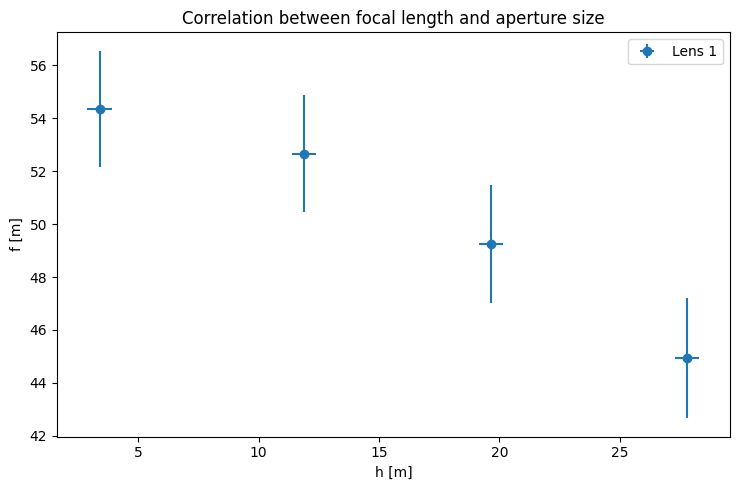

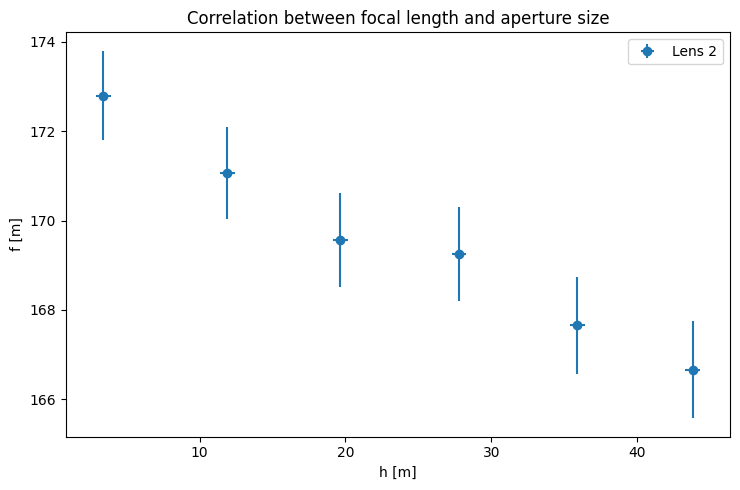

In [26]:
def f_BM_for_SA(lens):
    d = lens[:, 0]
    a = lens[:, 1]
    b = lens[:, 2]
    e = b - a

    return (d**2-e**2)/(4*d)

data_SA = np.loadtxt('SA.txt', delimiter=',')
sigma_h = 0.5

h_u = unumpy.uarray(data_SA[:,0], sigma_h)
d_a_b = unumpy.uarray(data_SA[:,1:], master_sigma)
f_SA= f_BM_for_SA(d_a_b)

lens_1_SA = np.array([h_u[:4], f_SA[:4]])
lens_2_SA = np.array([h_u[5:], f_SA[5:]])

# plot lens 1
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), xerr=unumpy.std_devs(lens_1_SA[0]), yerr=unumpy.std_devs(lens_1_SA[1]), fmt='o', label='Lens 1')

plt.xlabel('h [m]')
plt.ylabel('f [m]')
plt.title(f'Correlation between focal length and aperture size')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_lens_1.png', dpi=600)
plt.show()

# plot lens 2
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_2_SA[0]), unumpy.nominal_values(lens_2_SA[1]), xerr=unumpy.std_devs(lens_2_SA[0]), yerr=unumpy.std_devs(lens_2_SA[1]), fmt='o', label='Lens 2')

plt.xlabel('h [m]')
plt.ylabel('f [m]')
plt.title(f'Correlation between focal length and aperture size')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_lens_2.png', dpi=600)
plt.show()

# Correlation between focal length and aperture size

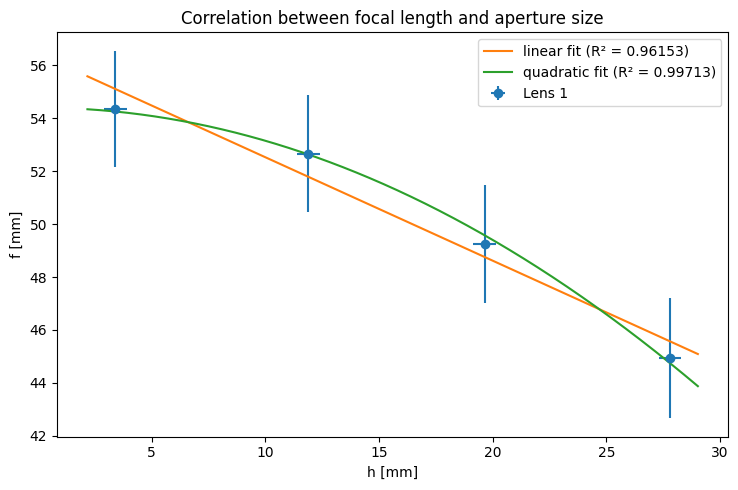

In [25]:
def linear(beta, h):
    m, y= beta
    return m*h+y

def quadratic(beta, h):
    a, f0 = beta
    return f0 + a*h**2

# linear fit
model = odr.Model(linear)
data = odr.RealData(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), sx=unumpy.std_devs(lens_1_SA[1]), sy=unumpy.std_devs(lens_1_SA[1]))
p0 = [1,1]
odr_run = odr.ODR(data, model, beta0=p0).run()

m_fit, y_fit = odr_run.beta
m_err, y_err = odr_run.sd_beta

m = ufloat(m_fit, m_err)
y = ufloat(y_fit, y_err)

# r2-score
y_hat_linear = linear(odr_run.beta, unumpy.nominal_values(lens_1_SA[0]))
ss_res_linear = np.sum((unumpy.nominal_values(lens_1_SA[1]) - y_hat_linear) ** 2)
ss_tot_linear = np.sum((unumpy.nominal_values(lens_1_SA[1]) - np.mean(unumpy.nominal_values(lens_1_SA[1]))) ** 2)
r_squared_linear = 1.0 - ss_res_linear / ss_tot_linear

# quadratic fit
model = odr.Model(quadratic)
odr_run = odr.ODR(data, model, beta0=p0).run()

a_fit, f0_fit = odr_run.beta
a_err, f0_err = odr_run.sd_beta

a = ufloat(a_fit, a_err)
f0 = ufloat(f0_fit, f0_err)

# r2-score
y_hat_quadratic = quadratic(odr_run.beta, unumpy.nominal_values(lens_1_SA[0]))
ss_res_quadratic = np.sum((unumpy.nominal_values(lens_1_SA[1]) - y_hat_quadratic) ** 2)
ss_tot_quadratic = np.sum((unumpy.nominal_values(lens_1_SA[1]) - np.mean(unumpy.nominal_values(lens_1_SA[1]))) ** 2)
r_squared_quadratic = 1.0 - ss_res_quadratic / ss_tot_quadratic

# plot
h_min, h_max = np.min(unumpy.nominal_values(lens_1_SA[0])), np.max(unumpy.nominal_values(lens_1_SA[0]))
h_pad = 0.05 * (h_max - h_min)
h_fit = np.linspace(h_min - h_pad, h_max + h_pad, 1000)

linear_fit  = linear([m_fit, y_fit], h_fit)
quadratic_fit = quadratic([a_fit, f0_fit], h_fit)

plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(unumpy.nominal_values(lens_1_SA[0]), unumpy.nominal_values(lens_1_SA[1]), xerr=unumpy.std_devs(lens_1_SA[0]), yerr=unumpy.std_devs(lens_1_SA[1]), fmt='o', label='Lens 1')
plt.plot(h_fit, linear_fit, '-', label=rf"linear fit (R² = {r_squared_linear:.5f})")
plt.plot(h_fit, quadratic_fit, '-', label=rf"quadratic fit (R² = {r_squared_quadratic:.5f})")
plt.xlabel('h [mm]')
plt.ylabel('f [mm]')
plt.title(f'Correlation between focal length and aperture size')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Spherical_Aberration_correlation.png', dpi=600)
plt.show()